In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

True

## 1. Chargement des Données


In [21]:
df = pd.read_csv('/content/911.csv')


In [22]:
print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')


Shape : (663522, 9)
Colonnes : ['lat', 'lng', 'desc', 'zip', 'title', 'timeStamp', 'twp', 'addr', 'e']


In [23]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


In [24]:
# ─── Aperçu général ──────────────────────────────────────────────────────────
print('=== Types & valeurs nulles ===')
print(df.dtypes)
print()
print('=== Valeurs manquantes ===')
print(df.isnull().sum())
print()


=== Types & valeurs nulles ===
lat          float64
lng          float64
desc          object
zip          float64
title         object
timeStamp     object
twp           object
addr          object
e              int64
dtype: object

=== Valeurs manquantes ===
lat              0
lng              0
desc             0
zip          80199
title            0
timeStamp        0
twp            293
addr             0
e                0
dtype: int64



##***Traitement des valeurs manquantes***

In [25]:
df = df.dropna(subset=['title', 'desc', 'timeStamp'])

df = df.drop(columns=['lat', 'lng', 'zip', 'addr', 'twp', 'e'])

# Réinitialiser l'index après suppression de lignes
df = df.reset_index(drop=True)

# Vérification propre
print(f"Shape après nettoyage : {df.shape}")
print(f"Nulls restants        : {df.isnull().sum().sum()}")
print(df.dtypes)

Shape après nettoyage : (663522, 3)
Nulls restants        : 0
desc         object
title        object
timeStamp    object
dtype: object


## 2. Ingénierie des Features — Extraction des Catégories


In [26]:
# La colonne `title` contient "CATÉGORIE: sous-type"
# Exemples : "EMS: CARDIAC EMERGENCY", "Fire: BUILDING FIRE", "Traffic: VEHICLE ACCIDENT"

df['category'] = df['title'].str.split(':').str[0].str.strip()
df['subcategory'] = df['title'].str.split(':').str[1].str.strip()


In [27]:
# Conversion datetime
df['timeStamp'] = pd.to_datetime(df['timeStamp'])
df['year']   = df['timeStamp'].dt.year
df['month']  = df['timeStamp'].dt.month
df['day']    = df['timeStamp'].dt.day
df['hour']   = df['timeStamp'].dt.hour
df['dayofweek'] = df['timeStamp'].dt.day_name()

print('Catégories principales :', df['category'].unique())
print('Distribution :')
print(df['category'].value_counts())


Catégories principales : ['EMS' 'Fire' 'Traffic']
Distribution :
category
EMS        332692
Traffic    230208
Fire       100622
Name: count, dtype: int64



## 3. Visualisations — Distribution des Classes



In [32]:
print("Taille df originale :", len(df))
print("Taille df_clean (si existant) :", len(df_clean) if 'df_clean' in globals() else "pas encore défini")
print("value_counts sur df :", df['category'].value_counts())

Taille df originale : 663522
Taille df_clean (si existant) : pas encore défini
value_counts sur df : category
EMS        332692
Traffic    230208
Fire       100622
Name: count, dtype: int64


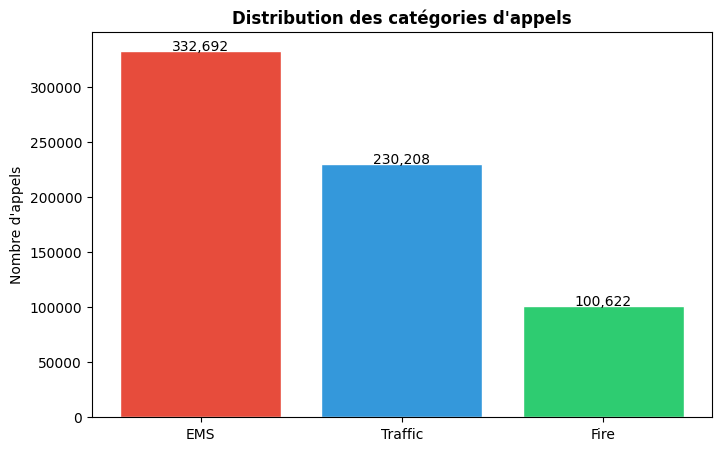

In [33]:
fig, ax = plt.subplots(figsize=(8,5))
cat_counts = df['category'].value_counts()
colors = ['#e74c3c', '#3498db', '#2ecc71']
ax.bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='white')
ax.set_title('Distribution des catégories d\'appels', fontweight='bold')
ax.set_ylabel('Nombre d\'appels')
for i, v in enumerate(cat_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center')
plt.show()

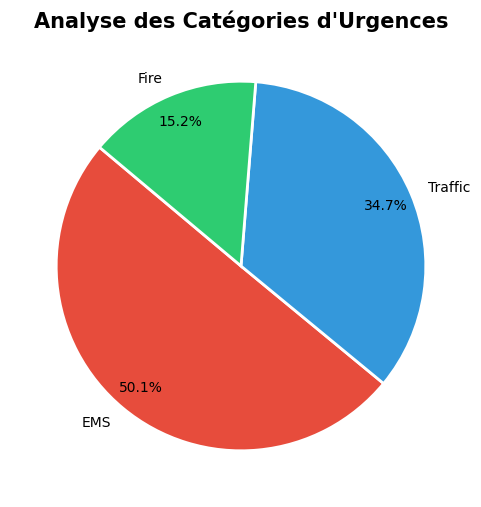

In [34]:
fig, ax = plt.subplots(figsize=(6,6))

ax.pie(cat_counts.values,
       labels=cat_counts.index,
       colors=colors,
       autopct='%1.1f%%',
       startangle=140,
       pctdistance=0.85,
       wedgeprops=dict(linewidth=2, edgecolor='white'))

ax.set_title('Répartition en %', fontsize=13, fontweight='bold')

plt.title("Analyse des Catégories d'Urgences", fontsize=15, fontweight='bold')
plt.show()

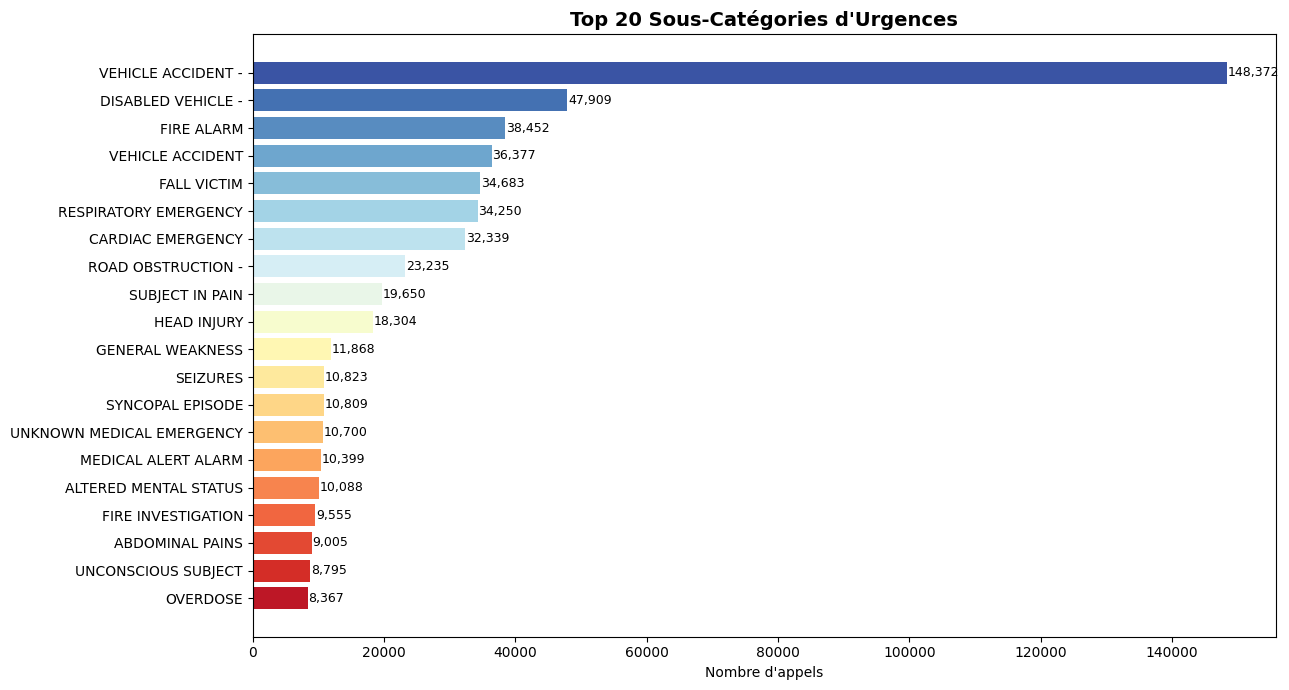

In [35]:
# Top 20 sous-catégories
fig, ax = plt.subplots(figsize=(13, 7))
top_sub = df['subcategory'].value_counts().head(20)

palette = sns.color_palette('RdYlBu', 20)
bars = ax.barh(top_sub.index[::-1], top_sub.values[::-1], color=palette)
ax.set_title('Top 20 Sous-Catégories d\'Urgences', fontsize=14, fontweight='bold')
ax.set_xlabel('Nombre d\'appels')
for bar in bars:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 4. Analyse Temporelle

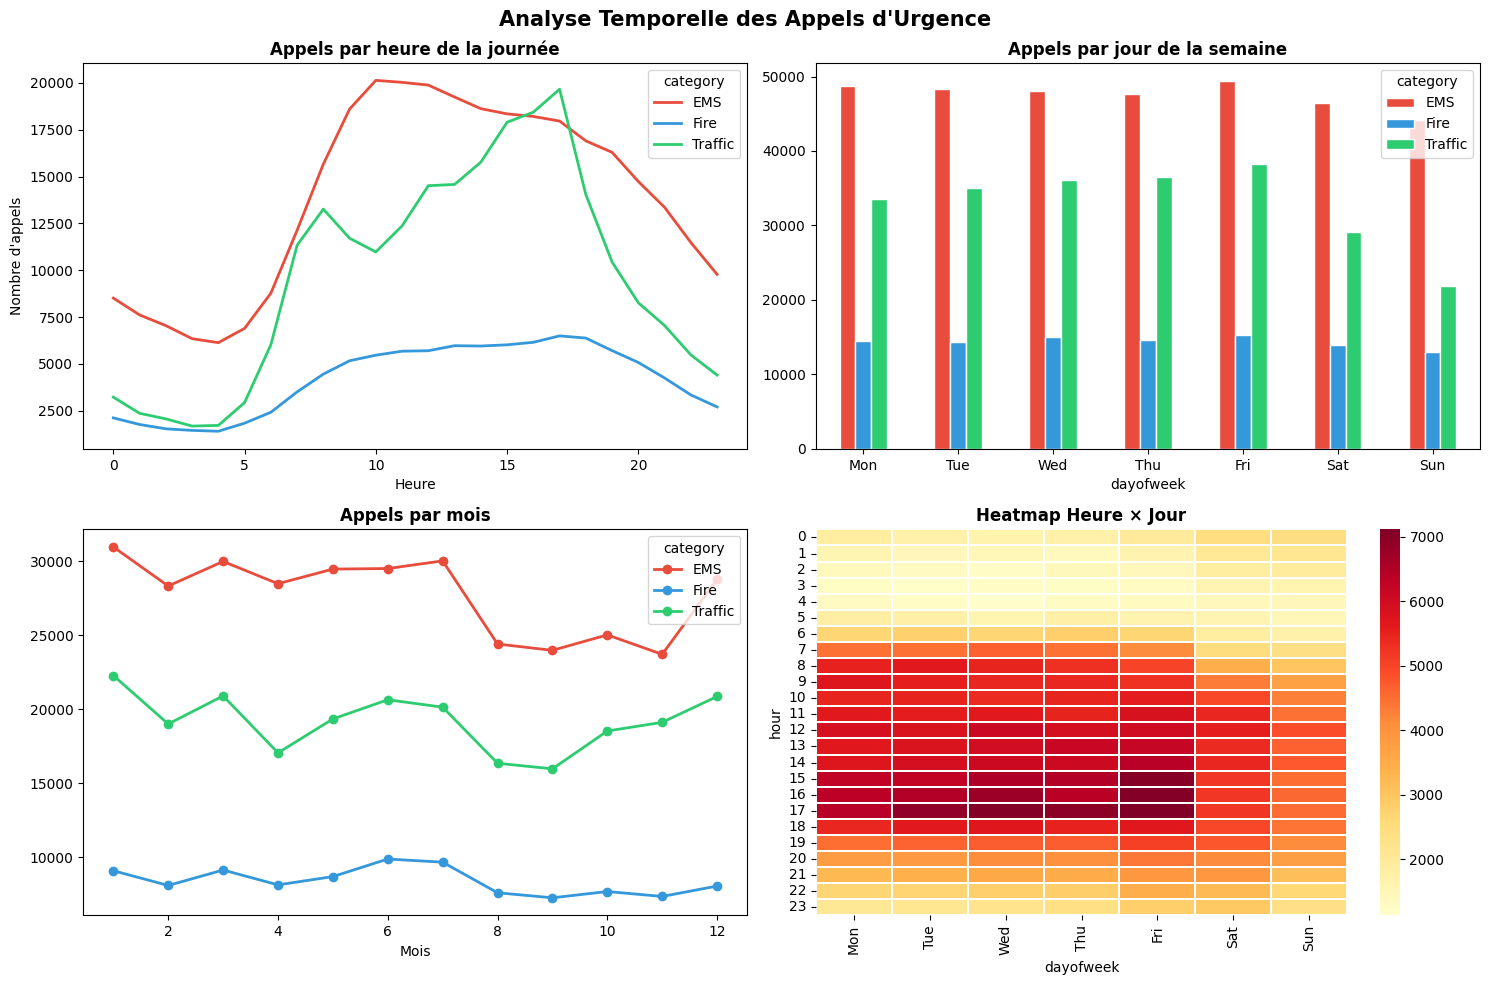

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Par heure
hourly = df.groupby(['hour', 'category']).size().unstack()
hourly.plot(ax=axes[0,0], color=['#e74c3c','#3498db','#2ecc71'], linewidth=2)
axes[0,0].set_title('Appels par heure de la journée', fontweight='bold')
axes[0,0].set_xlabel('Heure')
axes[0,0].set_ylabel('Nombre d\'appels')

# Par jour de la semaine
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby(['dayofweek','category']).size().unstack().reindex(order)
daily.plot(kind='bar', ax=axes[0,1], color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[0,1].set_title('Appels par jour de la semaine', fontweight='bold')
axes[0,1].set_xticklabels([d[:3] for d in order], rotation=0)

# Par mois
monthly = df.groupby(['month','category']).size().unstack()
monthly.plot(ax=axes[1,0], color=['#e74c3c','#3498db','#2ecc71'], marker='o', linewidth=2)
axes[1,0].set_title('Appels par mois', fontweight='bold')
axes[1,0].set_xlabel('Mois')

# Heatmap heure x jour
pivot = df.pivot_table(index='hour', columns='dayofweek',  aggfunc='size')
pivot = pivot.reindex(columns=order)
sns.heatmap(pivot, ax=axes[1,1], cmap='YlOrRd', linewidths=.3)
axes[1,1].set_title('Heatmap Heure × Jour', fontweight='bold')
axes[1,1].set_xticklabels([d[:3] for d in order])

plt.suptitle('Analyse Temporelle des Appels d\'Urgence', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Prétraitement NLP


In [37]:
from collections import Counter

text = df['title'].fillna('').str.lower() + ' ' + df['desc'].fillna('').str.lower()

all_words = ' '.join(text).split()

word_counts = Counter(all_words)

print(word_counts.most_common(30))

[('@', 663528), ('&', 624577), ('station', 334984), ('ems:', 332692), ('vehicle', 240120), ('rd', 233617), ('-', 233488), ('traffic:', 230208), ('rd;', 221126), ('accident', 184787), ('lower', 124061), ('upper', 116585), ('st', 108782), ('st;', 103516), ('ave;', 100773), ('fire:', 100622), ('ave', 93670), ('merion;', 91500), ('emergency', 84082), ('fire', 78916), ('pike', 68772), ('dr;', 55688), ('alarm', 48851), ('disabled', 47917), ('dr', 45571), ('w', 41819), ('abington;', 39947), ('victim', 39381), ('cardiac', 39146), ('providence;', 38598)]


In [38]:
stop_words = set(stopwords.words('english'))

domain_stopwords = {
    'station', 'unit', 'nbm', 'medic', 'cp', 'pa',
    'ems', 'fire', 'traffic'
}
stop_words.update(domain_stopwords)

def clean_text(text):
    """Nettoyage et normalisation du texte."""

    if pd.isna(text):
        return ''

    text = text.lower()

    # suppression chiffres + ponctuation
    text = re.sub(r'[^a-z\s]', ' ', text)

    tokens = word_tokenize(text)

    tokens = [
        t for t in tokens
        if t not in stop_words and len(t) > 2
    ]

    return ' '.join(tokens)


In [39]:
import nltk
nltk.download('punkt_tab', quiet=True)

# Appliquer sur desc + title
df['text_combined'] = df['subcategory'].fillna('') + ' ' + df['desc'].fillna('')
df['text_clean'] = df['text_combined'].apply(clean_text)

print('Exemple original  :', df['text_combined'].iloc[0])
print('Exemple nettoyé   :', df['text_clean'].iloc[0])
for word in ['ems', 'fire', 'traffic']:
    print(word, df['text_clean'].str.contains(r'\b' + word + r'\b').sum())

Exemple original  : BACK PAINS/INJURY REINDEER CT & DEAD END;  NEW HANOVER; Station 332; 2015-12-10 @ 17:10:52;
Exemple nettoyé   : back pains injury reindeer dead end new hanover
ems 0
fire 0
traffic 0


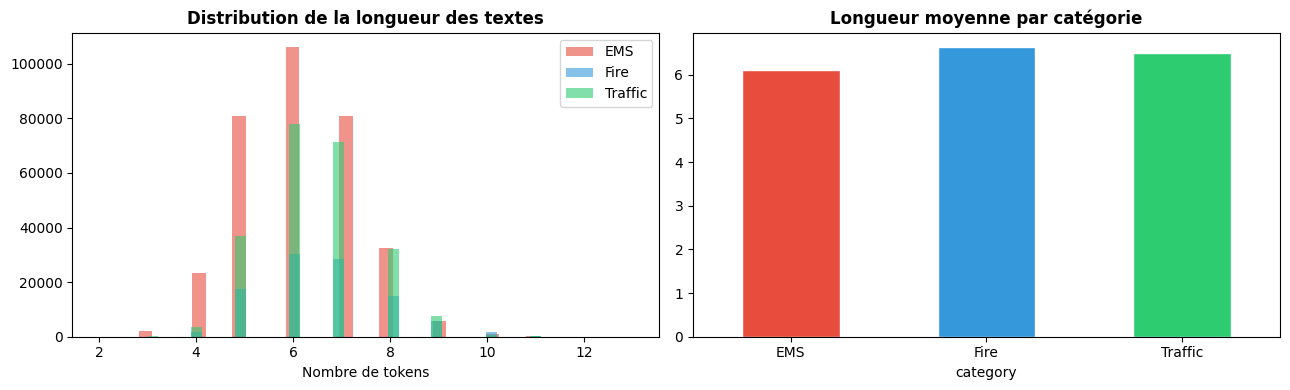

In [40]:
# Longueur des textes
df['text_length'] = df['text_clean'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for cat, color in zip(df['category'].unique(), ['#e74c3c','#3498db','#2ecc71']):
    subset = df[df['category'] == cat]['text_length']
    axes[0].hist(subset, bins=40, alpha=0.6, label=cat, color=color)
axes[0].set_title('Distribution de la longueur des textes', fontweight='bold')
axes[0].set_xlabel('Nombre de tokens')
axes[0].legend()

df.groupby('category')['text_length'].mean().plot(kind='bar', ax=axes[1],
    color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
axes[1].set_title('Longueur moyenne par catégorie', fontweight='bold')
axes[1].set_xticklabels(df['category'].unique(), rotation=0)

plt.tight_layout()
plt.show()

In [41]:
print('Stats longueur texte :')
print(df.groupby('category')['text_length'].describe().round(1))


Stats longueur texte :
             count  mean  std  min  25%  50%  75%   max
category                                               
EMS       332692.0   6.1  1.2  2.0  5.0  6.0  7.0  13.0
Fire      100622.0   6.6  1.3  3.0  6.0  7.0  7.0  12.0
Traffic   230208.0   6.5  1.1  3.0  6.0  6.0  7.0  12.0


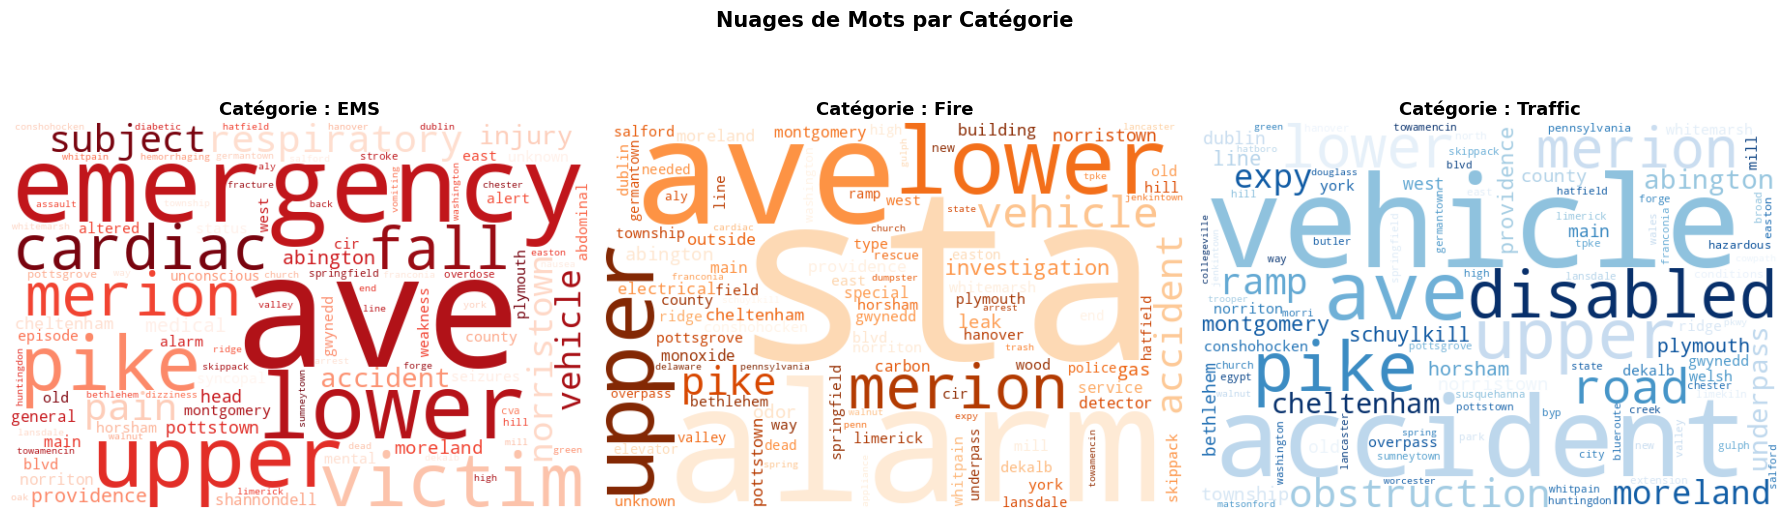

In [43]:
# Word Clouds par catégorie
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cat_colors = {'EMS': 'Reds', 'Fire': 'Oranges', 'Traffic': 'Blues'}

for ax, (cat, cmap) in zip(axes, cat_colors.items()):
    text = ' '.join(df[df['category'] == cat]['text_clean'])
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmap, max_words=100, collocations=False)
    wc.generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Catégorie : {cat}', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Nuages de Mots par Catégorie', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

6.Analyse du Vocabulaire

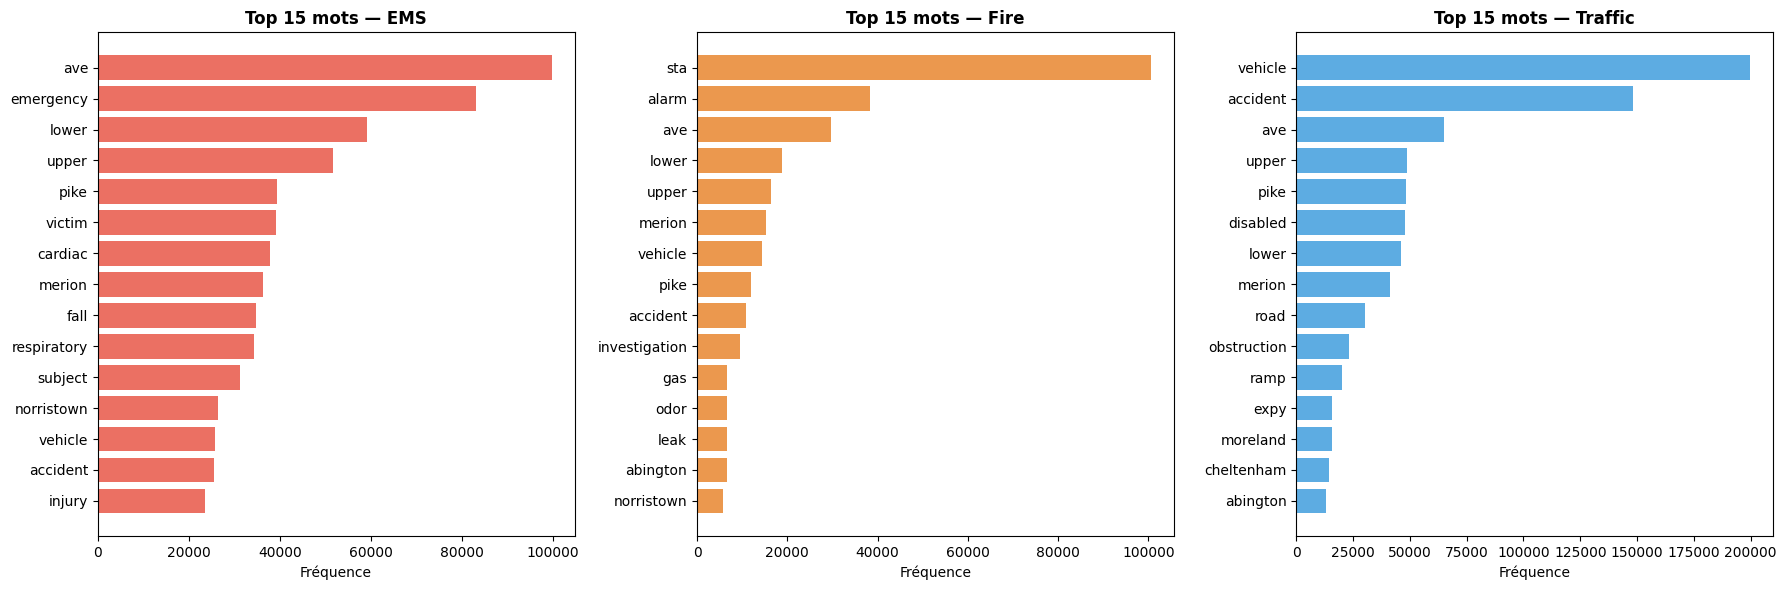

In [44]:
# Mots les plus fréquents par catégorie
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (cat, color) in zip(axes, [('EMS','#e74c3c'), ('Fire','#e67e22'), ('Traffic','#3498db')]):
    all_words = ' '.join(df[df['category'] == cat]['text_clean']).split()
    freq = Counter(all_words).most_common(15)
    words, counts = zip(*freq)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.8)
    ax.set_title(f'Top 15 mots — {cat}', fontweight='bold')
    ax.set_xlabel('Fréquence')

plt.tight_layout()
plt.show()


In [45]:
# Taille du vocabulaire global
all_tokens = ' '.join(df['text_clean']).split()
vocab = set(all_tokens)
print(f'Taille du corpus    : {len(all_tokens):,} tokens')
print(f'Taille du vocabulaire : {len(vocab):,} mots uniques')
print(f'Token le plus fréquent : {Counter(all_tokens).most_common(1)[0]}')


Taille du corpus    : 4,195,135 tokens
Taille du vocabulaire : 6,001 mots uniques
Token le plus fréquent : ('vehicle', 240120)


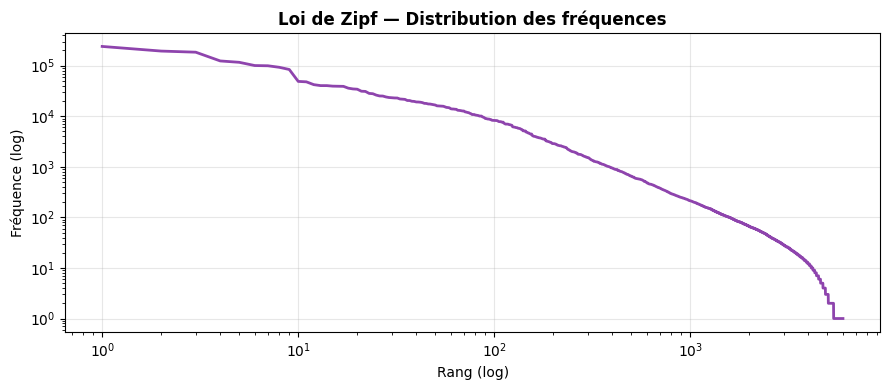

In [46]:
# Courbe de Zipf
freq_sorted = sorted(Counter(all_tokens).values(), reverse=True)
plt.figure(figsize=(9, 4))
plt.loglog(range(1, len(freq_sorted)+1), freq_sorted, color='#8e44ad', linewidth=2)
plt.title('Loi de Zipf — Distribution des fréquences', fontweight='bold')
plt.xlabel('Rang (log)')
plt.ylabel('Fréquence (log)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Encodage des Labels & Split Train/Val/Test



In [47]:
# Encoder les catégories
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

print('Encoder les catégories :')
for i, cls in enumerate(le.classes_):
    count = (df['label'] == i).sum()
    print(f'  {i} → {cls:10s} ({count:,} exemples)')


Encoder les catégories :
  0 → EMS        (332,692 exemples)
  1 → Fire       (100,622 exemples)
  2 → Traffic    (230,208 exemples)


In [48]:
df_clean = df[df['text_clean'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'\nDataset final : {len(df_clean):,} exemples')


Dataset final : 663,522 exemples


In [49]:
# Split 70 / 15 / 15
from sklearn.model_selection import train_test_split

# Filter out the single-instance class (the 'nan' category, which has label 3)
# Based on previous cell execution and value counts, the 'nan' category was encoded as label 3 and has only one example.
#df_filtered = df_clean[df_clean['label'] != 3].copy() # Using .copy() to avoid SettingWithCopyWarning

X = df_clean['text_clean']
y = df_clean['label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train : {len(X_train):,} exemples')
print(f'Val   : {len(X_val):,} exemples')
print(f'Test  : {len(X_test):,} exemples')

Train : 464,465 exemples
Val   : 99,528 exemples
Test  : 99,529 exemples


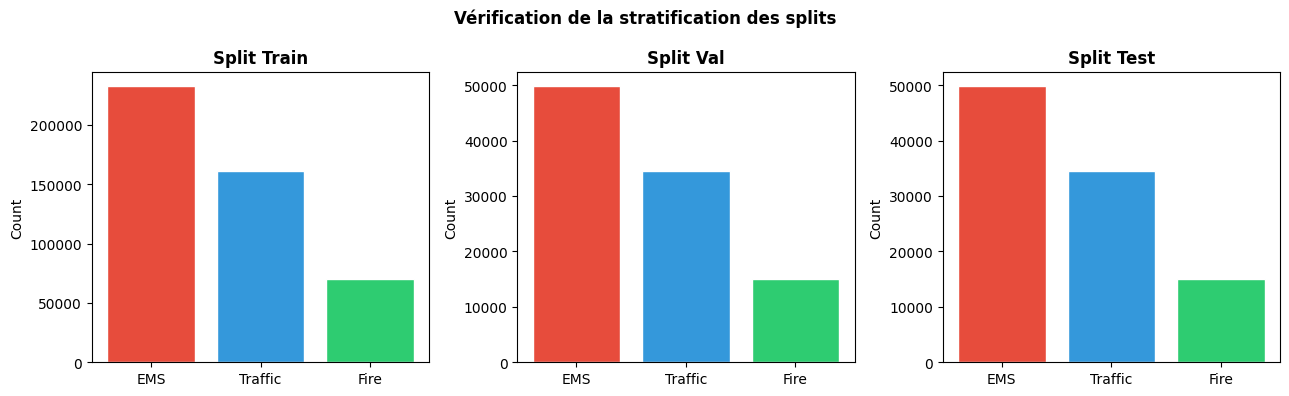

In [50]:
# Vérifier la stratification
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (split_y, name) in zip(axes, [(y_train,'Train'),(y_val,'Val'),(y_test,'Test')]):
    counts = pd.Series(split_y).map(dict(enumerate(le.classes_))).value_counts()
    ax.bar(counts.index, counts.values, color=['#e74c3c','#3498db','#2ecc71'], edgecolor='white')
    ax.set_title(f'Split {name}', fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Vérification de la stratification des splits', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Sauvegarde des Données Preprocessées


In [51]:
# Sauvegarder le dataset nettoyé
df_clean[['text_combined', 'text_clean', 'category', 'label',
          'hour', 'dayofweek', 'month']].to_csv('911_preprocessed.csv', index=False)

print(' Fichier 911_preprocessed.csv sauvegardé')
print()
print('=== Résumé pour le Deep Learning ===')
print(f'  Nombre de classes    : {len(le.classes_)}')
print(f'  Classes              : {list(le.classes_)}')
print(f'  Taille vocabulaire   : {len(vocab):,}')
print(f'  Longueur moy. texte  : {df_clean["text_length"].mean():.1f} tokens')
print(f'  Longueur max texte   : {df_clean["text_length"].max()} tokens')
print(f'  Taille Train/Val/Test: {len(X_train):,} / {len(X_val):,} / {len(X_test):,}')


 Fichier 911_preprocessed.csv sauvegardé

=== Résumé pour le Deep Learning ===
  Nombre de classes    : 3
  Classes              : ['EMS', 'Fire', 'Traffic']
  Taille vocabulaire   : 6,001
  Longueur moy. texte  : 6.3 tokens
  Longueur max texte   : 13 tokens
  Taille Train/Val/Test: 464,465 / 99,528 / 99,529


## 9. Architectures Deep Learning Recommandées


In [52]:
!pip install torch torchvision transformers scikit-learn pandas numpy matplotlib seaborn tqdm -q


In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR


In [54]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f' Device : {DEVICE}')
print(f'PyTorch  : {torch.__version__}')


 Device : cpu
PyTorch  : 2.10.0+cpu


In [55]:
# ─── Chargement du dataset préprocessé ──────────────────────────────────────
df = pd.read_csv('911_preprocessed.csv')
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

NUM_CLASSES = len(le.classes_)
CLASS_NAMES = list(le.classes_)

X_train, X_temp, y_train, y_temp = train_test_split(
    df['text_clean'], df['label'], test_size=0.30, random_state=SEED, stratify=df['label'])
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f'Classes : {CLASS_NAMES}')
print(f'Train/Val/Test : {len(X_train):,} / {len(X_val):,} / {len(X_test):,}')

Classes : ['EMS', 'Fire', 'Traffic']
Train/Val/Test : 464,465 / 99,528 / 99,529


## Modèle 1 — LSTM Bidirectionnel

In [56]:
# ── Vocabulaire & Tokenisation simple ────────────────────────────────────────
from collections import Counter
from torch.nn.utils.rnn import pad_sequence

MAX_VOCAB = 30_000
MAX_LEN   = 64
PAD_IDX   = 0
UNK_IDX   = 1

# Construction du vocabulaire sur le train uniquement
all_tokens = ' '.join(X_train).split()
counter    = Counter(all_tokens)
vocab      = ['<PAD>', '<UNK>'] + [w for w, _ in counter.most_common(MAX_VOCAB - 2)]
word2idx   = {w: i for i, w in enumerate(vocab)}

def encode(text, max_len=MAX_LEN):
    ids = [word2idx.get(w, UNK_IDX) for w in str(text).split()[:max_len]]
    return ids

print(f'Taille vocabulaire : {len(word2idx):,}')

class EmergencyDatasetLSTM(Dataset):
    def __init__(self, texts, labels, max_len=MAX_LEN):
        self.data = [(encode(t, max_len), l) for t, l in zip(texts, labels)]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ids, label = self.data[idx]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

def collate_fn(batch):
    seqs, labels = zip(*batch)
    seqs_padded  = pad_sequence(seqs, batch_first=True, padding_value=PAD_IDX)
    return seqs_padded, torch.stack(labels)

BS = 128
train_dl_lstm = DataLoader(EmergencyDatasetLSTM(X_train, y_train), batch_size=BS,
                            shuffle=True, collate_fn=collate_fn)
val_dl_lstm   = DataLoader(EmergencyDatasetLSTM(X_val,   y_val),   batch_size=BS,
                            collate_fn=collate_fn)
test_dl_lstm  = DataLoader(EmergencyDatasetLSTM(X_test,  y_test),  batch_size=BS,
                            collate_fn=collate_fn)
print(' DataLoaders LSTM prêts')

Taille vocabulaire : 5,765
 DataLoaders LSTM prêts


In [58]:
with open('vocab.txt', 'w', encoding='utf-8') as f:
    for word in vocab:
        f.write(word + '\n')

In [59]:
class SelfAttention(nn.Module):
    """Attention additive sur la séquence LSTM."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out):        # (B, T, 2H)
        scores  = self.attn(lstm_out).squeeze(-1)   # (B, T)
        weights = torch.softmax(scores, dim=1)       # (B, T)
        context = (lstm_out * weights.unsqueeze(-1)).sum(dim=1)  # (B, 2H)
        return context


class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 num_layers=2, num_classes=3, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            bidirectional=True, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.attention = SelfAttention(hidden_dim)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb     = self.dropout(self.embedding(x))   # (B, T, E)
        out, _  = self.lstm(emb)                    # (B, T, 2H)
        context = self.attention(out)               # (B, 2H)
        logits  = self.fc(self.dropout(context))    # (B, C)
        return logits

NUM_CLASSES = len(le.classes_)
lstm_model = BiLSTMClassifier(len(word2idx), num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f'Paramètres BiLSTM : {total_params:,}')
print(lstm_model)

Paramètres BiLSTM : 3,107,460
BiLSTMClassifier(
  (embedding): Embedding(5765, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (attention): SelfAttention(
    (attn): Linear(in_features=512, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=512, out_features=3, bias=True)
)


In [60]:
import time
def train_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss += loss.item() * len(y)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds_all, labels_all = [], []
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        logits = model(X)
        loss   = criterion(logits, y)
        total_loss += loss.item() * len(y)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total   += len(y)
        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(y.cpu().numpy())
    return total_loss / total, correct / total, preds_all, labels_all

def run_training(model, train_dl, val_dl, epochs=10, lr=1e-3, model_name='model'):
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_acc, best_state = 0, None

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_dl, optimizer, criterion)
        vl_loss, vl_acc, _, _ = eval_epoch(model, val_dl, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

        print(f'[{model_name}] Epoch {epoch:02d}/{epochs} | '
              f'Loss {tr_loss:.4f}/{vl_loss:.4f} | '
              f'Acc {tr_acc:.4f}/{vl_acc:.4f} | {time.time()-t0:.1f}s')

    model.load_state_dict(best_state)
    print(f'\n Meilleure val_acc : {best_val_acc:.4f}')
    return history


In [61]:
# ── Entraînement BiLSTM ───────────────────────────────────────────────────────
history_lstm = run_training(lstm_model, train_dl_lstm, val_dl_lstm, epochs=10, lr=1e-3, model_name='BiLSTM')


[BiLSTM] Epoch 01/10 | Loss 0.0870/0.0700 | Acc 0.9720/0.9789 | 1991.9s
[BiLSTM] Epoch 02/10 | Loss 0.0704/0.0663 | Acc 0.9789/0.9798 | 2005.1s
[BiLSTM] Epoch 03/10 | Loss 0.0678/0.0645 | Acc 0.9798/0.9809 | 2012.8s
[BiLSTM] Epoch 04/10 | Loss 0.0658/0.0634 | Acc 0.9801/0.9812 | 1997.1s
[BiLSTM] Epoch 05/10 | Loss 0.0644/0.0629 | Acc 0.9805/0.9811 | 2012.9s
[BiLSTM] Epoch 06/10 | Loss 0.0631/0.0637 | Acc 0.9807/0.9812 | 2002.2s
[BiLSTM] Epoch 07/10 | Loss 0.0619/0.0627 | Acc 0.9810/0.9812 | 2006.2s
[BiLSTM] Epoch 08/10 | Loss 0.0611/0.0633 | Acc 0.9811/0.9813 | 2005.3s
[BiLSTM] Epoch 09/10 | Loss 0.0607/0.0634 | Acc 0.9811/0.9814 | 2001.9s
[BiLSTM] Epoch 10/10 | Loss 0.0601/0.0634 | Acc 0.9812/0.9813 | 2017.1s

 Meilleure val_acc : 0.9814


In [62]:
print(f"Taille train_dl_lstm : {len(train_dl_lstm)}")
print(f"Taille val_dl_lstm   : {len(val_dl_lstm)}")

Taille train_dl_lstm : 3629
Taille val_dl_lstm   : 778


##Modèle-2 CNN 1D

In [69]:
class TextCNN(nn.Module):
    """
    CNN à noyaux multiples (Kim 2014) pour la classification de texte.
    Chaque noyau capture des n-grammes de taille différente.
    """
    def __init__(self, vocab_size, embed_dim=128, num_filters=128,
                 kernel_sizes=(3, 4, 5), num_classes=3, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):                          # (B, T)
        emb = self.embedding(x).permute(0, 2, 1)  # (B, E, T)
        pooled = []
        for conv in self.convs:
            h = F.relu(conv(emb))                  # (B, F, T-k+1)
            h = h.max(dim=-1).values               # (B, F)  — global max-pool
            pooled.append(h)
        cat    = torch.cat(pooled, dim=1)          # (B, F*len(kernels))
        logits = self.fc(self.dropout(cat))
        return logits


In [70]:
cnn_model = TextCNN(len(word2idx), num_classes=NUM_CLASSES).to(DEVICE)
print(f'Paramètres CNN : {sum(p.numel() for p in cnn_model.parameters()):,}')


Paramètres CNN : 936,067


In [71]:
history_cnn = run_training(cnn_model, train_dl_lstm, val_dl_lstm,
                            epochs=10, lr=1e-3, model_name='CNN1D')



[CNN1D] Epoch 01/10 | Loss 0.0937/0.0742 | Acc 0.9708/0.9788 | 278.0s
[CNN1D] Epoch 02/10 | Loss 0.0759/0.0724 | Acc 0.9778/0.9800 | 269.4s
[CNN1D] Epoch 03/10 | Loss 0.0716/0.0707 | Acc 0.9789/0.9792 | 237.8s
[CNN1D] Epoch 04/10 | Loss 0.0690/0.0694 | Acc 0.9796/0.9805 | 250.3s
[CNN1D] Epoch 05/10 | Loss 0.0664/0.0694 | Acc 0.9799/0.9808 | 277.8s
[CNN1D] Epoch 06/10 | Loss 0.0643/0.0687 | Acc 0.9803/0.9805 | 285.3s
[CNN1D] Epoch 07/10 | Loss 0.0621/0.0686 | Acc 0.9805/0.9806 | 274.6s
[CNN1D] Epoch 08/10 | Loss 0.0603/0.0687 | Acc 0.9809/0.9807 | 293.7s
[CNN1D] Epoch 09/10 | Loss 0.0590/0.0688 | Acc 0.9811/0.9806 | 300.9s
[CNN1D] Epoch 10/10 | Loss 0.0578/0.0691 | Acc 0.9811/0.9806 | 326.5s

 Meilleure val_acc : 0.9808


## 5. Évaluation finale sur le Test Set


In [72]:
@torch.no_grad()
def predict_lstm(model, loader):
    model.eval()
    preds, labels = [], []
    for X, y in loader:
        preds.extend(model(X.to(DEVICE)).argmax(1).cpu().numpy())
        labels.extend(y.numpy())
    return np.array(preds), np.array(labels)

@torch.no_grad()
def predict_transformer(model, loader):
    model.eval()
    preds, labels = [], []
    for batch in loader:
        out = model(input_ids=batch['input_ids'].to(DEVICE),
                    attention_mask=batch['attention_mask'].to(DEVICE))
        preds.extend(out.logits.argmax(1).cpu().numpy())
        labels.extend(batch['labels'].numpy())
    return np.array(preds), np.array(labels)


In [73]:
# Prédictions sur le test
p_lstm,   l_lstm   = predict_lstm(lstm_model, test_dl_lstm)
p_cnn,    l_cnn    = predict_lstm(cnn_model,  test_dl_lstm)


results = {
    'BiLSTM':     (p_lstm, l_lstm),
    'CNN1D':      (p_cnn,  l_cnn),

}


In [74]:
from sklearn.metrics import accuracy_score, f1_score
print('=== Résultats sur le Test Set ===')
print(f'{"Modèle":<15} {"Accuracy":>10} {"F1 Macro":>10} {"F1 Weighted":>13}')
print('-' * 50)
for name, (pred, true) in results.items():
    acc = accuracy_score(true, pred)
    f1m = f1_score(true, pred, average='macro')
    f1w = f1_score(true, pred, average='weighted')
    print(f'{name:<15} {acc:>10.4f} {f1m:>10.4f} {f1w:>13.4f}')


=== Résultats sur le Test Set ===
Modèle            Accuracy   F1 Macro   F1 Weighted
--------------------------------------------------
BiLSTM              0.9817     0.9852        0.9818
CNN1D               0.9809     0.9845        0.9809


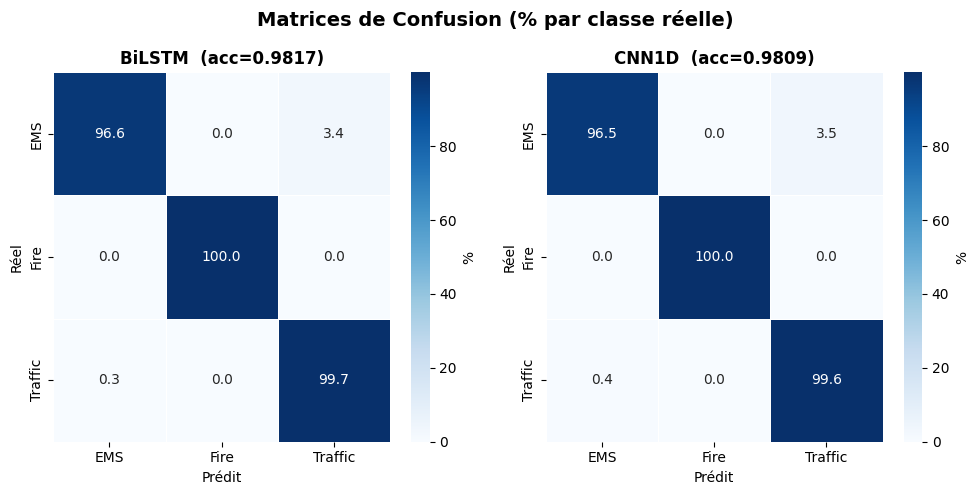

In [75]:
# ── Matrices de confusion ─────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, (name, (pred, true)) in zip(axes.flat, results.items()):
    cm = confusion_matrix(true, pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, cbar_kws={'label': '%'})
    acc = accuracy_score(true, pred)
    ax.set_title(f'{name}  (acc={acc:.4f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')

plt.suptitle('Matrices de Confusion (% par classe réelle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

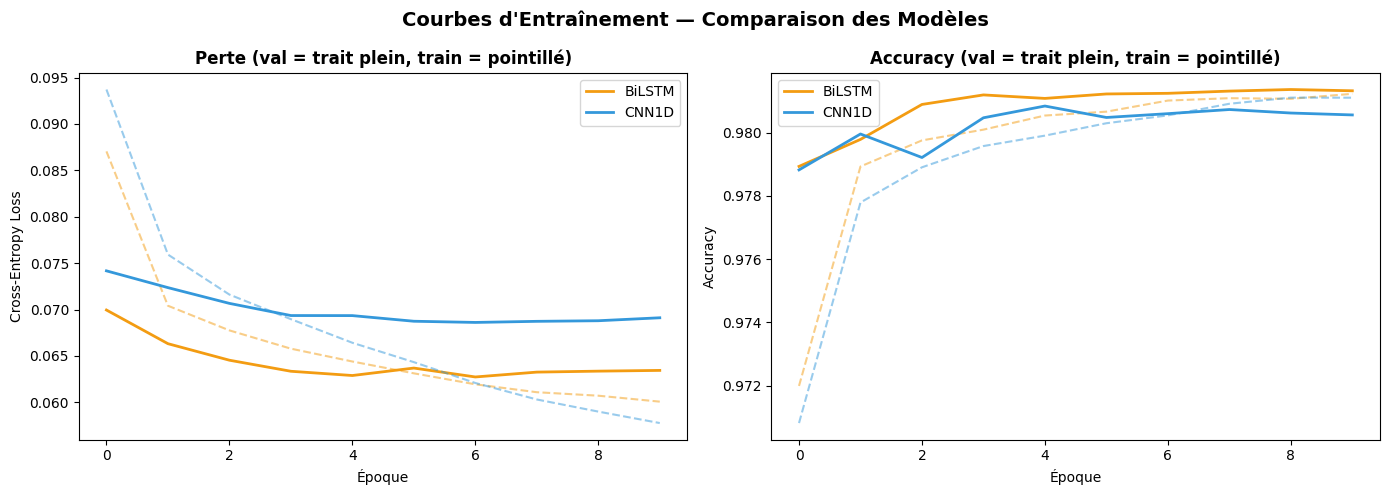

In [76]:
# ── Courbes d'entraînement comparatives ──────────────────────────────────────
histories = {
    'BiLSTM':     history_lstm,
    'CNN1D':      history_cnn,
}
colors = ['#f39c12', '#3498db']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, h), color in zip(histories.items(), colors):
    axes[0].plot(h['train_loss'], '--', color=color, alpha=0.5)
    axes[0].plot(h['val_loss'],   '-',  color=color, label=name, linewidth=2)
    axes[1].plot(h['train_acc'],  '--', color=color, alpha=0.5)
    axes[1].plot(h['val_acc'],    '-',  color=color, label=name, linewidth=2)

axes[0].set_title('Perte (val = trait plein, train = pointillé)', fontweight='bold')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()

axes[1].set_title('Accuracy (val = trait plein, train = pointillé)', fontweight='bold')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Courbes d\'Entraînement — Comparaison des Modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [77]:
# ── Rapport de classification détaillé (meilleur modèle) ─────────────────────
# Choisir le modèle avec la meilleure accuracy
from sklearn.metrics import classification_report
best_name = max(results, key=lambda n: accuracy_score(results[n][1], results[n][0]))
best_pred, best_true = results[best_name]

print(f'=== Rapport détaillé — {best_name} ===')
print(classification_report(best_true, best_pred, target_names=CLASS_NAMES, digits=4))


=== Rapport détaillé — BiLSTM ===
              precision    recall  f1-score   support

         EMS     0.9978    0.9657    0.9815     49904
        Fire     0.9999    0.9999    0.9999     15094
     Traffic     0.9527    0.9969    0.9743     34531

    accuracy                         0.9817     99529
   macro avg     0.9834    0.9875    0.9852     99529
weighted avg     0.9825    0.9817    0.9818     99529



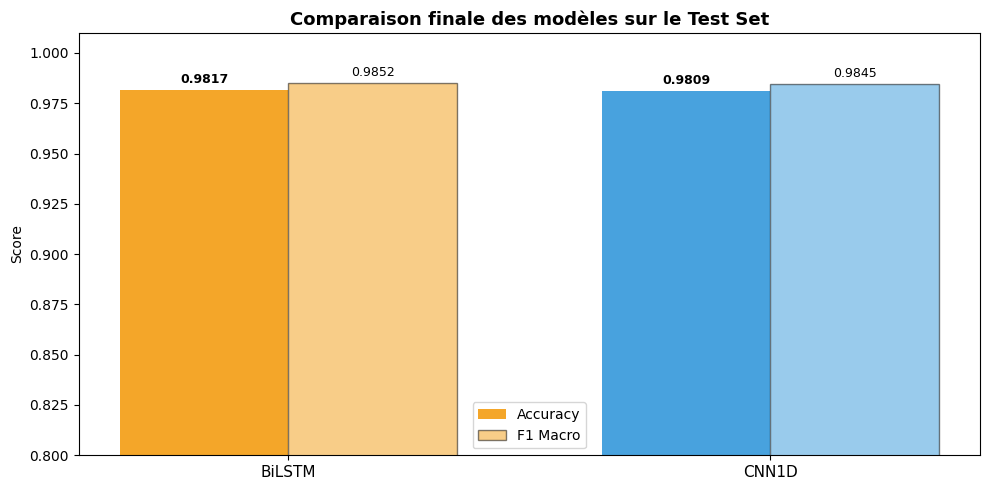

In [78]:
# ── Bar chart comparatif final ────────────────────────────────────────────────
model_names = list(results.keys())
acc_scores  = [accuracy_score(results[n][1], results[n][0]) for n in model_names]
f1_scores   = [f1_score(results[n][1], results[n][0], average='macro') for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, acc_scores, width, label='Accuracy',  color=colors, alpha=0.9)
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1 Macro', color=colors, alpha=0.5, edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0.8, 1.01)
ax.set_ylabel('Score')
ax.set_title('Comparaison finale des modèles sur le Test Set', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [79]:
print(f'\n🏆 Meilleur modèle : {best_name} avec Accuracy = {max(acc_scores):.4f}')



🏆 Meilleur modèle : BiLSTM avec Accuracy = 0.9817


## 6. Sauvegarde du meilleur modèle







In [80]:

import os
import torch

In [81]:
# Création du dossier de sauvegarde

os.makedirs("saved_models", exist_ok=True)

print("Dossier prêt : saved_models/")

Dossier prêt : saved_models/


In [82]:
# Sélection du meilleur modèle

if best_name == "BiLSTM":
    best_model = lstm_model

elif best_name == "CNN1D":
    best_model = cnn_model

else:
    raise ValueError("Nom du modèle inconnu")

print("Meilleur modèle sélectionné :", best_name)

Meilleur modèle sélectionné : BiLSTM


In [83]:
# Sauvegarde complète du modèle

checkpoint = {

    # Nom du modèle
    "model_name": best_name,

    # Poids du modèle
    "model_state_dict": best_model.state_dict(),

    # Dictionnaire vocabulaire
    "word2idx": word2idx,

    # Classes des labels
    "classes": le.classes_,

    # Longueur maximale des séquences
    "max_len": MAX_LEN
}

torch.save(
    checkpoint,
    "saved_models/best_model.pt"
)

print("Modèle sauvegardé avec succès !")
print("Fichier : saved_models/best_model.pt")

Modèle sauvegardé avec succès !
Fichier : saved_models/best_model.pt


In [84]:
# Vérification du contenu sauvegardé

loaded_checkpoint = torch.load(
    "saved_models/best_model.pt",
    map_location="cpu",
    weights_only=False
)

print("Nom du modèle :", loaded_checkpoint["model_name"])
print("Nombre de mots du vocabulaire :", len(loaded_checkpoint["word2idx"]))
print("Classes :", loaded_checkpoint["classes"])
print("MAX_LEN :", loaded_checkpoint["max_len"])

Nom du modèle : BiLSTM
Nombre de mots du vocabulaire : 5765
Classes : ['EMS' 'Fire' 'Traffic']
MAX_LEN : 64


##  Interface Gradio






In [85]:
!pip install gradio -q

In [86]:
import gradio as gr
import torch
import re
from nltk.tokenize import word_tokenize

In [103]:
import gradio as gr
import torch
import re
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

# ── 1. Vocabulaire ────────────────────────────────────────────────────────────
with open("vocab.txt", "r", encoding="utf-8") as f:
    vocab = [line.strip() for line in f.readlines()]
word2idx = {w: i for i, w in enumerate(vocab)}
print(f" Vocabulaire : {len(word2idx):,} mots")

# ── 2. Chargement modèle ──────────────────────────────────────────────────────
ck      = torch.load("saved_models/best_model.pt", map_location="cpu", weights_only=False)
classes = list(ck["classes"])
MAX_LEN = ck["max_len"]

model = BiLSTMClassifier(
    vocab_size  = len(word2idx),
    embed_dim   = 128,
    hidden_dim  = 256,
    num_layers  = 2,
    num_classes = len(classes),
    dropout     = 0.4,
)
model.load_state_dict(ck["model_state_dict"])
model.eval()
print(f" Modèle chargé — classes : {classes}")

# ── 3. Preprocessing ──────────────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
stop_words.update({'station', 'unit', 'nbm', 'medic', 'cp', 'pa'})

def clean_text(text):
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

def encode(text):
    UNK = word2idx.get('<UNK>', 1)
    return [word2idx.get(w, UNK) for w in text.split()[:MAX_LEN]]



# ── 5. Interface ──────────────────────────────────────────────────────────────
with gr.Blocks() as demo:
    gr.Markdown("# 🚨 Classifieur d'Appels d'Urgence 911")
    inp = gr.Textbox(label="Description de l'appel", lines=3)
    btn = gr.Button("Classifier", variant="primary")
    out = gr.Markdown()
    btn.click(fn=predict, inputs=inp, outputs=out)

demo.launch(share=True)

 Vocabulaire : 5,765 mots
 Modèle chargé — classes : ['EMS', 'Fire', 'Traffic']
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1c8d4173561273808f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
